In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from sklearn.model_selection import GroupShuffleSplit

In [ ]:
# Path to the folder containing all .npz files
DATA_DIR = "../data/"

# Labeled image filenames
LABELED_FILES = ["O013257.npz", "O013490.npz", "O012791.npz"]

# Column names based on the lab description
COLUMNS = [
    "y", "x", "NDAI", "SD", "CORR",
    "Radiance_DF", "Radiance_CF", "Radiance_BF", "Radiance_AF", "Radiance_AN",
    "label"
]

# Plot style
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

In [3]:
def load_npz_as_array(file_path):
    """
    Load a .npz file and return the first array inside it.
    This is robust to different internal key names.
    """
    data = np.load(file_path)
    keys = list(data.keys())
    if len(keys) == 0:
        raise ValueError(f"No array found in {file_path}")
    arr = data[keys[0]]
    return arr


def to_dataframe(arr, file_name):
    """
    Convert numpy array to a pandas DataFrame.
    Supports labeled and unlabeled files.
    """
    if arr.shape[1] == 11:
        df = pd.DataFrame(arr, columns=COLUMNS)
    elif arr.shape[1] == 10:
        df = pd.DataFrame(arr, columns=COLUMNS[:-1])
        df["label"] = 0
    else:
        raise ValueError(f"Unexpected number of columns: {arr.shape[1]}")
    
    df["image_id"] = file_name
    return df


def clean_dataframe(df):
    """
    Basic cleaning:
    1. Replace inf with NaN
    2. Drop rows with missing essential values
    3. Keep only valid labels {-1, 0, 1}
    4. Remove duplicate rows
    """
    df = df.copy()
    
    df = df.replace([np.inf, -np.inf], np.nan)
    
    essential_cols = ["x", "y", "NDAI", "SD", "CORR",
                      "Radiance_DF", "Radiance_CF", "Radiance_BF", "Radiance_AF", "Radiance_AN", "label"]
    df = df.dropna(subset=essential_cols)
    
    df = df[df["label"].isin([-1, 0, 1])]
    
    # Remove exact duplicate rows
    df = df.drop_duplicates()
    
    return df.reset_index(drop=True)


def labeled_only(df):
    """
    Keep only expert-labeled pixels.
    label = +1 means cloud
    label = -1 means non-cloud
    label = 0 means unlabeled
    """
    return df[df["label"].isin([-1, 1])].copy()


def label_to_name(label):
    if label == 1:
        return "Cloud"
    elif label == -1:
        return "Non-cloud"
    return "Unlabeled"

In [4]:
dfs = []

for fname in LABELED_FILES:
    path = os.path.join(DATA_DIR, fname)
    arr = load_npz_as_array(path)
    df = to_dataframe(arr, fname)
    df = clean_dataframe(df)
    dfs.append(df)

all_labeled_raw = pd.concat(dfs, ignore_index=True)
all_labeled = labeled_only(all_labeled_raw)

print("Loaded labeled files:")
for fname, df in zip(LABELED_FILES, dfs):
    print(f"{fname}: {df.shape[0]:,} rows after cleaning")

print("\nOnly expert-labeled pixels:")
print(all_labeled["label"].value_counts().sort_index())

Loaded labeled files:
O013257.npz: 115,000 rows after cleaning
O013490.npz: 115,032 rows after cleaning
O012791.npz: 114,973 rows after cleaning

Only expert-labeled pixels:
label
-1.0    126716
 1.0     80965
Name: count, dtype: int64


In [5]:
print(all_labeled.columns)

Index(['y', 'x', 'NDAI', 'SD', 'CORR', 'Radiance_DF', 'Radiance_CF',
       'Radiance_BF', 'Radiance_AF', 'Radiance_AN', 'label', 'image_id'],
      dtype='str')


In [6]:
summary_rows = []

for fname in LABELED_FILES:
    df = all_labeled_raw[all_labeled_raw["image_id"] == fname].copy()
    summary_rows.append({
        "image_id": fname,
        "total_rows_after_cleaning": len(df),
        "cloud_pixels": (df["label"] == 1).sum(),
        "noncloud_pixels": (df["label"] == -1).sum(),
        "unlabeled_pixels": (df["label"] == 0).sum(),
        "missing_rate_after_cleaning": df.isna().mean().mean()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,image_id,total_rows_after_cleaning,cloud_pixels,noncloud_pixels,unlabeled_pixels,missing_rate_after_cleaning
0,O013257.npz,115000,20468,50358,44174,0.0
1,O013490.npz,115032,39253,42830,32949,0.0
2,O012791.npz,114973,21244,33528,60201,0.0


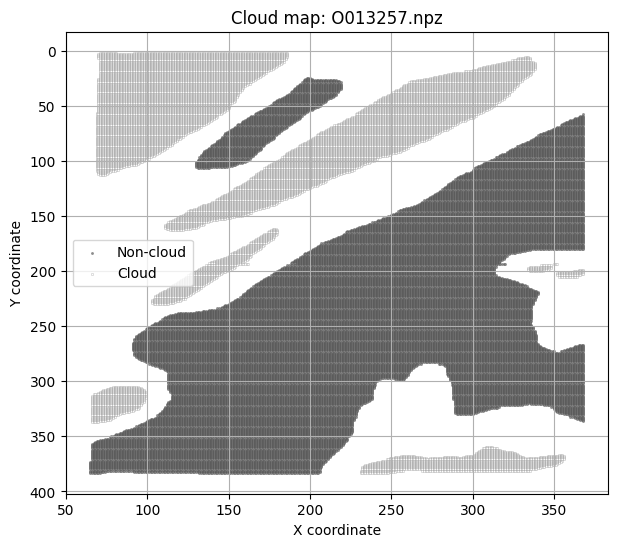

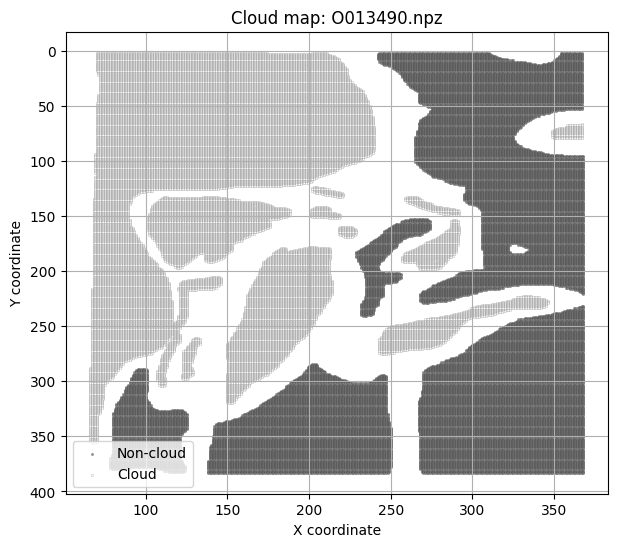

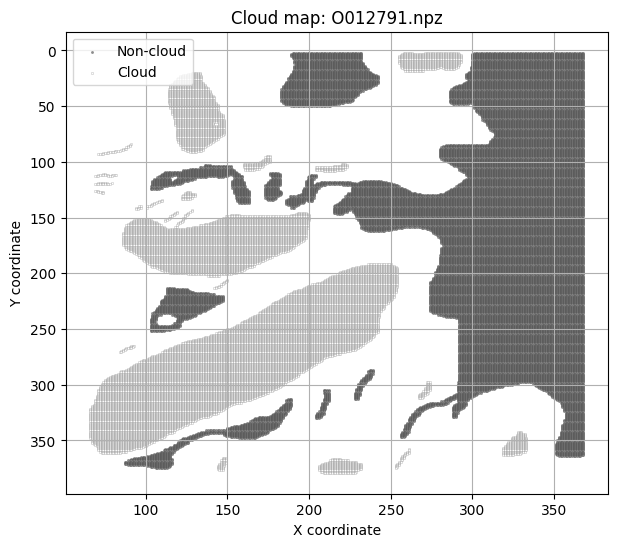

In [7]:
def plot_cloud_map(df, title):
    """
    Plot expert labels using x-y coordinates.
    """
    plot_df = df[df["label"].isin([-1, 1])].copy()
    
    color_map = {1: "white", -1: "gray"}
    edge_map = {1: "black", -1: "black"}
    
    plt.figure(figsize=(7, 6))
    
    for lab in [-1, 1]:
        sub = plot_df[plot_df["label"] == lab]
        plt.scatter(
            sub["x"], sub["y"],
            s=3,
            c=color_map[lab],
            edgecolors=edge_map[lab],
            linewidths=0.1,
            label=label_to_name(lab),
            alpha=0.9
        )
    
    plt.gca().invert_yaxis()
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(title)
    plt.legend()
    plt.show()


for fname in LABELED_FILES:
    df_img = all_labeled_raw[all_labeled_raw["image_id"] == fname]
    plot_cloud_map(df_img, f"Cloud map: {fname}")

In [8]:
class_balance = (
    all_labeled
    .groupby(["image_id", "label"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={-1: "Non-cloud", 1: "Cloud"})
)

class_balance["Cloud_ratio"] = class_balance["Cloud"] / (class_balance["Cloud"] + class_balance["Non-cloud"])
class_balance

label,Non-cloud,Cloud,Cloud_ratio
image_id,,,
O012791.npz,33528,21244,0.387862
O013257.npz,50358,20468,0.288990
O013490.npz,42830,39253,0.478211


In [9]:
radiance_cols = ["Radiance_DF", "Radiance_CF", "Radiance_BF", "Radiance_AF", "Radiance_AN"]
feature_cols = ["NDAI", "SD", "CORR"] + radiance_cols

summary_stats = (
    all_labeled
    .groupby("label")[feature_cols]
    .agg(["mean", "std", "median"])
)

summary_stats.index = ["Non-cloud", "Cloud"]
summary_stats

NDAI                              SD                          \
               mean       std    median        mean         std      median   
Non-cloud  0.142714  0.043273  0.138407  163.763015  443.071977   42.260296   
Cloud      0.264589  0.126909  0.252943  723.741661  529.914618  585.036194   

               CORR                       Radiance_DF  ... Radiance_CF  \
               mean       std    median          mean  ...      median   
Non-cloud  0.366549  0.422800  0.359038  27456.423926  ...   27342.375   
Cloud      0.413331  0.383378  0.442920  27997.866775  ...   24498.000   

            Radiance_BF                         Radiance_AF               \
                   mean          std   median          mean          std   
Non-cloud  24192.799444  3330.847468  25480.0  22200.413738  2915.754900   
Cloud      20384.505907  4635.317262  21216.5  17869.253254  4766.890389   

                      Radiance_AN                         
             median          mean          std    median  
Non-cloud  23484.25  20605.630073  2520.904636  21457.25  
Cloud      18919.25  16567.729476  4645.536735  17611.25  

[2 rows x 24 columns]

In [10]:
def standardized_mean_difference(x_cloud, x_clear):
    """
    Compute standardized mean difference.
    Larger absolute values indicate stronger separation.
    """
    mean_diff = x_cloud.mean() - x_clear.mean()
    pooled_std = np.sqrt((x_cloud.var(ddof=1) + x_clear.var(ddof=1)) / 2)
    if pooled_std == 0:
        return np.nan
    return mean_diff / pooled_std

sep_rows = []

cloud_df = all_labeled[all_labeled["label"] == 1]
clear_df = all_labeled[all_labeled["label"] == -1]

for col in feature_cols:
    score = standardized_mean_difference(cloud_df[col], clear_df[col])
    sep_rows.append({
        "feature": col,
        "standardized_mean_difference": score,
        "absolute_value": abs(score)
    })

sep_df = pd.DataFrame(sep_rows).sort_values("absolute_value", ascending=False)
sep_df

,feature,standardized_mean_difference,absolute_value
0,NDAI,1.285455,1.285455
1,SD,1.146494,1.146494
6,Radiance_AF,-1.096147,1.096147
7,Radiance_AN,-1.080410,1.080410
5,Radiance_BF,-0.943550,0.943550
4,Radiance_CF,-0.523078,0.523078
3,Radiance_DF,0.121655,0.121655
2,CORR,0.115921,0.115921


/tmp/ipykernel_2818/4175989205.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)


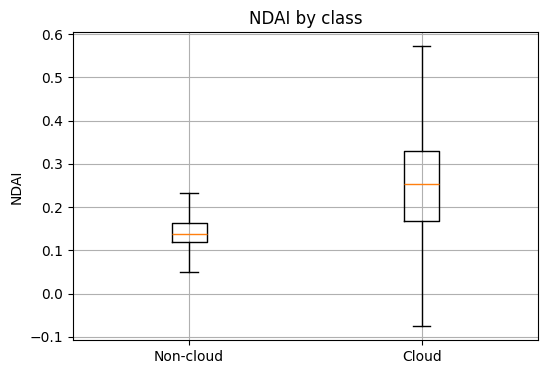

/tmp/ipykernel_2818/4175989205.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)


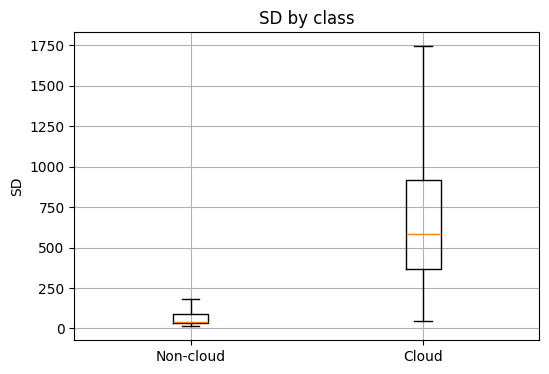

/tmp/ipykernel_2818/4175989205.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)


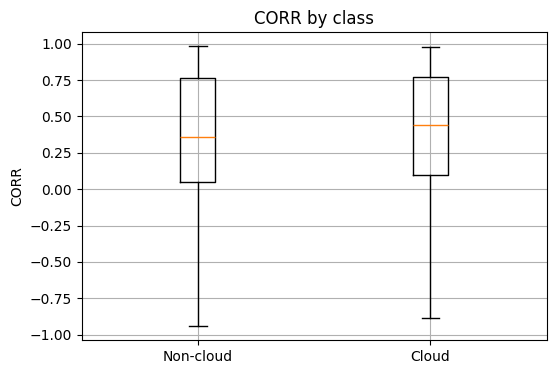

/tmp/ipykernel_2818/4175989205.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)


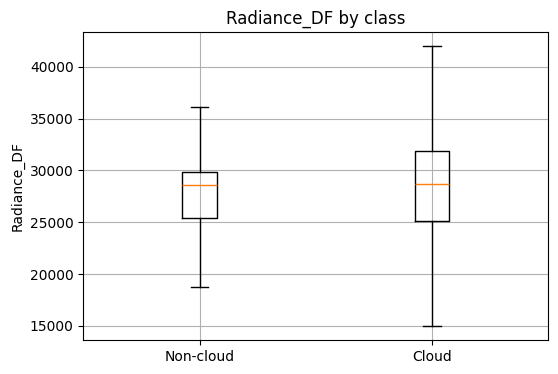

/tmp/ipykernel_2818/4175989205.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)


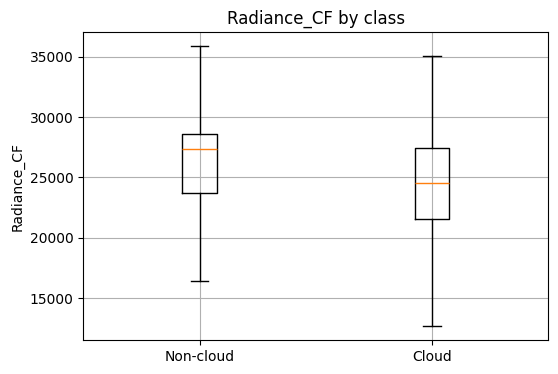

/tmp/ipykernel_2818/4175989205.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)


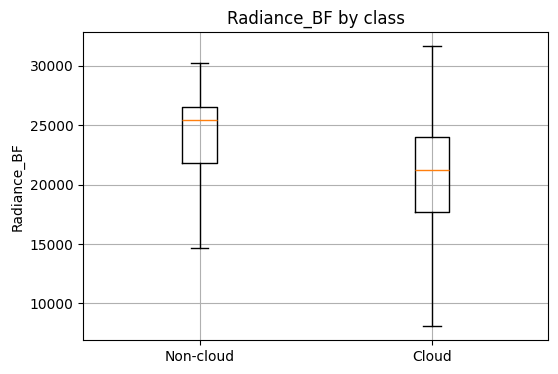

/tmp/ipykernel_2818/4175989205.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)


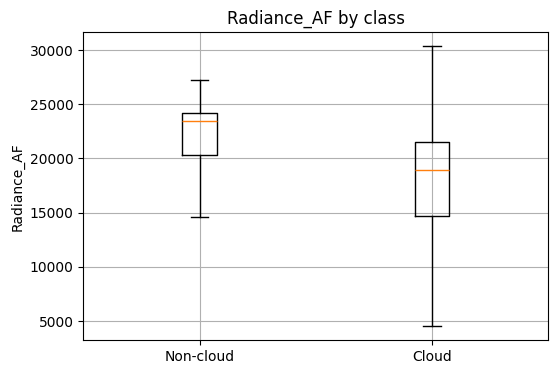

/tmp/ipykernel_2818/4175989205.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)


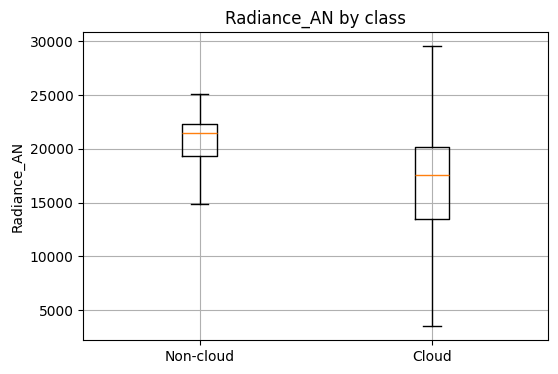

In [11]:
plot_cols = ["NDAI", "SD", "CORR", "Radiance_DF", "Radiance_CF", "Radiance_BF", "Radiance_AF", "Radiance_AN"]

for col in plot_cols:
    plt.figure(figsize=(6, 4))
    data_to_plot = [
        all_labeled.loc[all_labeled["label"] == -1, col],
        all_labeled.loc[all_labeled["label"] == 1, col]
    ]
    plt.boxplot(data_to_plot, labels=["Non-cloud", "Cloud"], showfliers=False)
    plt.title(f"{col} by class")
    plt.ylabel(col)
    plt.show()

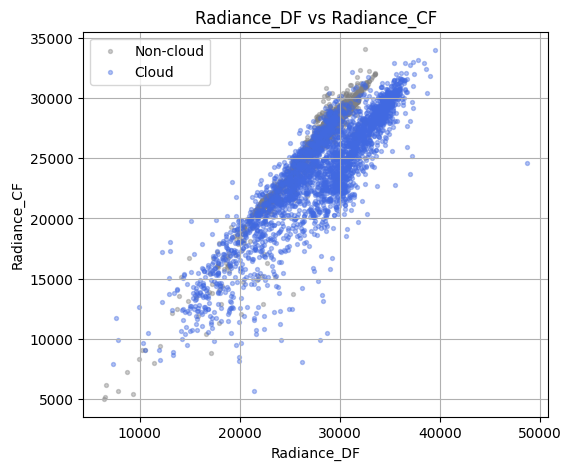

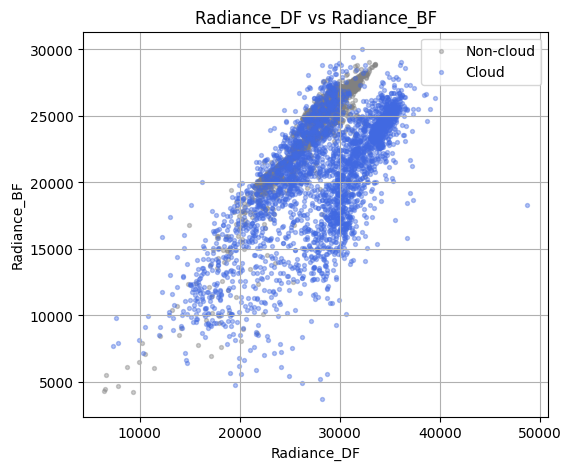

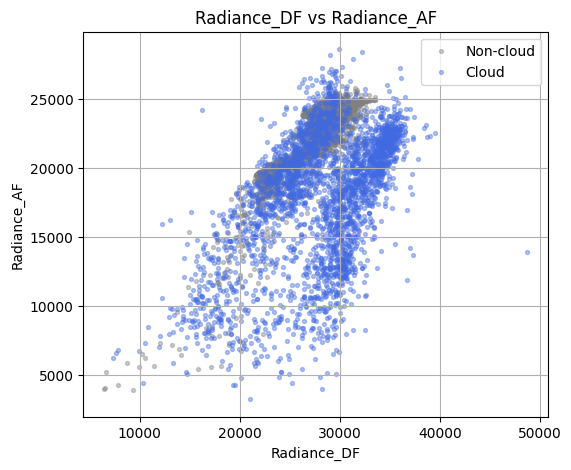

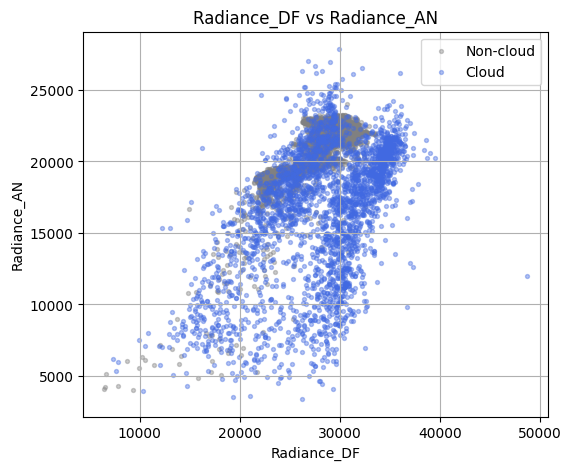

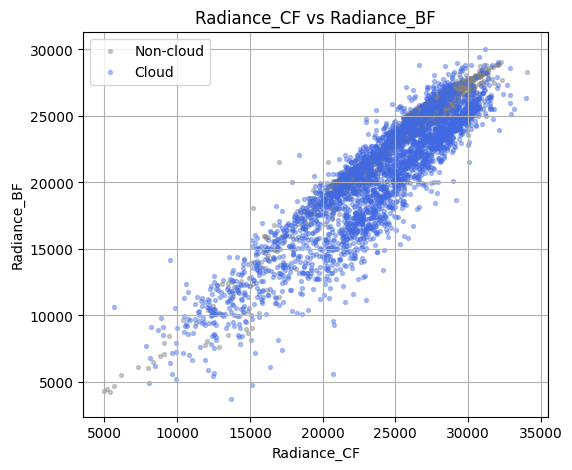

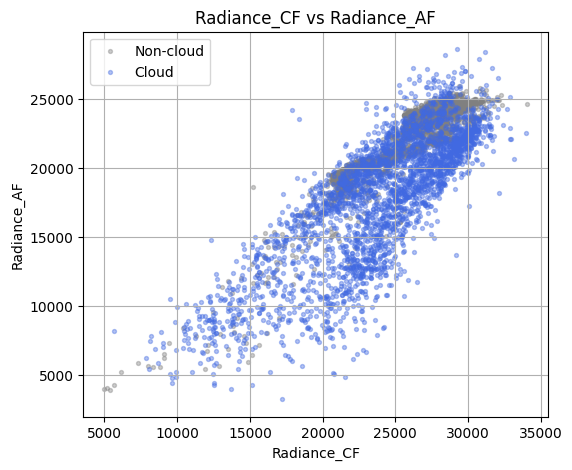

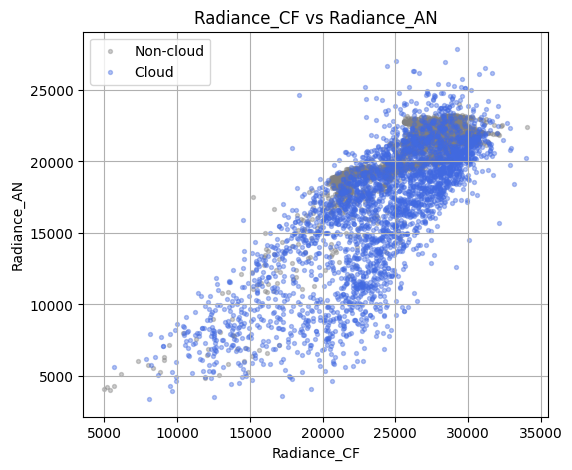

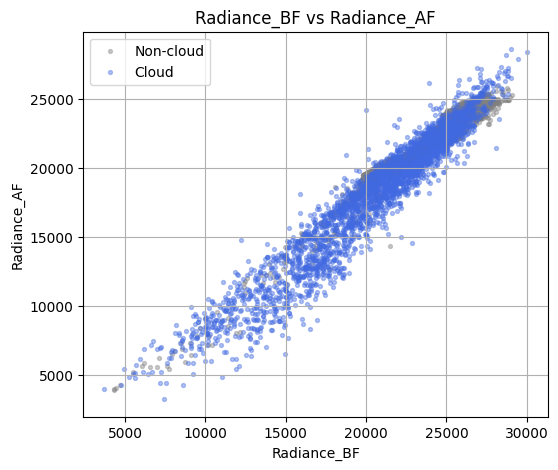

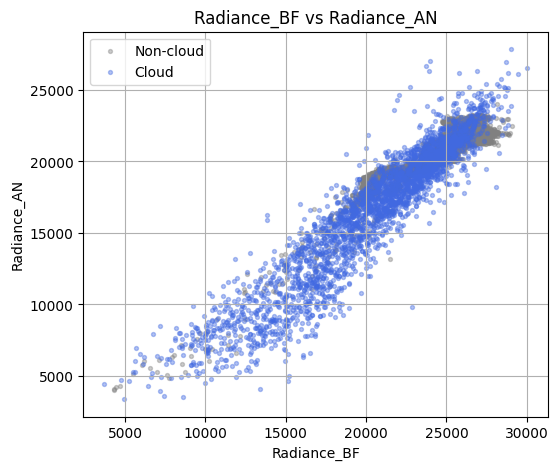

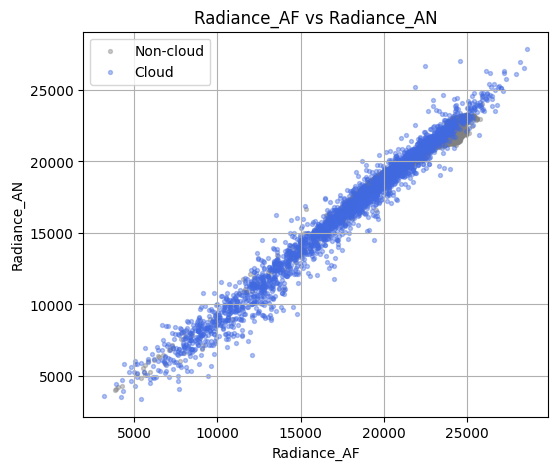

In [12]:
angle_pairs = list(combinations(radiance_cols, 2))

# Sample points for plotting to avoid overplotting
sample_parts = []
for lab in [-1, 1]:
    sub = all_labeled[all_labeled["label"] == lab].copy()
    sub = sub.sample(n=min(3000, len(sub)), random_state=42)
    sample_parts.append(sub)

sample_df = pd.concat(sample_parts, ignore_index=True)

color_map = {-1: "gray", 1: "royalblue"}
label_name_map = {-1: "Non-cloud", 1: "Cloud"}

for c1, c2 in angle_pairs:
    plt.figure(figsize=(6, 5))
    for lab in [-1, 1]:
        sub = sample_df[sample_df["label"] == lab]
        plt.scatter(
            sub[c1],
            sub[c2],
            s=8,
            alpha=0.4,
            c=color_map[lab],
            label=label_name_map[lab]
        )
    plt.xlabel(c1)
    plt.ylabel(c2)
    plt.title(f"{c1} vs {c2}")
    plt.legend()
    plt.show()

In [13]:
print(sample_df.columns)

Index(['y', 'x', 'NDAI', 'SD', 'CORR', 'Radiance_DF', 'Radiance_CF',
       'Radiance_BF', 'Radiance_AF', 'Radiance_AN', 'label', 'image_id'],
      dtype='str')


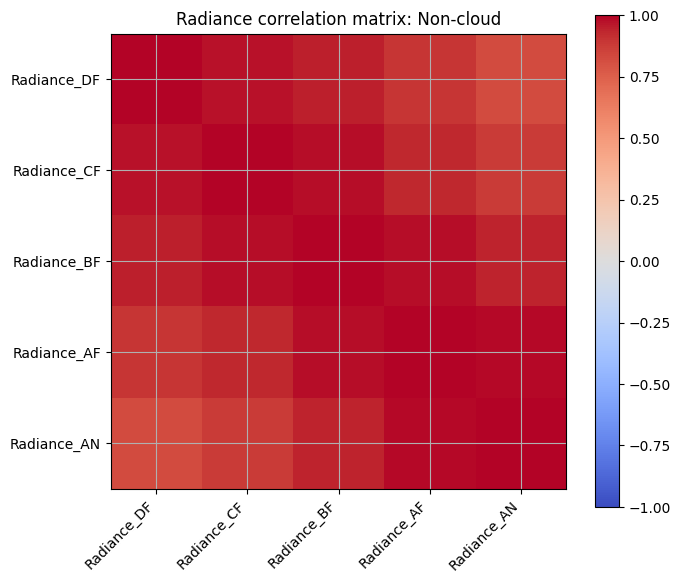

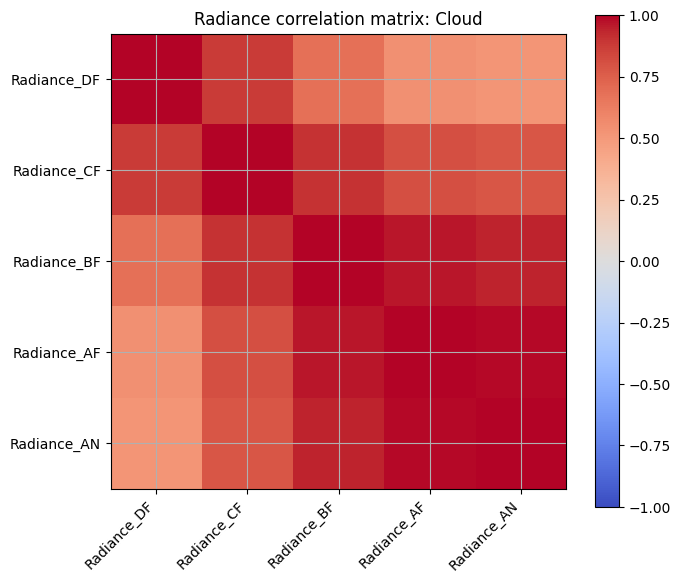

Non-cloud correlation matrix:


,Radiance_DF,Radiance_CF,Radiance_BF,Radiance_AF,Radiance_AN
Radiance_DF,1.000000,0.974625,0.947026,0.892774,0.823456
Radiance_CF,0.974625,1.000000,0.983650,0.937385,0.881304
Radiance_BF,0.947026,0.983650,1.000000,0.979901,0.939616
Radiance_AF,0.892774,0.937385,0.979901,1.000000,0.985230
Radiance_AN,0.823456,0.881304,0.939616,0.985230,1.000000


Cloud correlation matrix:


,Radiance_DF,Radiance_CF,Radiance_BF,Radiance_AF,Radiance_AN
Radiance_DF,1.000000,0.878808,0.680398,0.541391,0.519329
Radiance_CF,0.878808,1.000000,0.904140,0.807601,0.784939
Radiance_BF,0.680398,0.904140,1.000000,0.963415,0.942247
Radiance_AF,0.541391,0.807601,0.963415,1.000000,0.987238
Radiance_AN,0.519329,0.784939,0.942247,0.987238,1.000000


In [14]:
def plot_corr_matrix(df, cols, title):
    corr = df[cols].corr()
    
    plt.figure(figsize=(7, 6))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
    plt.yticks(range(len(cols)), cols)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    return corr

corr_noncloud = plot_corr_matrix(
    all_labeled[all_labeled["label"] == -1],
    radiance_cols,
    "Radiance correlation matrix: Non-cloud"
)

corr_cloud = plot_corr_matrix(
    all_labeled[all_labeled["label"] == 1],
    radiance_cols,
    "Radiance correlation matrix: Cloud"
)

print("Non-cloud correlation matrix:")
display(corr_noncloud)

print("Cloud correlation matrix:")
display(corr_cloud)

In [15]:
corr_diff = corr_cloud - corr_noncloud
print("Difference in correlation matrices (Cloud - Non-cloud):")
display(corr_diff)

Difference in correlation matrices (Cloud - Non-cloud):


,Radiance_DF,Radiance_CF,Radiance_BF,Radiance_AF,Radiance_AN
Radiance_DF,0.000000,-0.095818,-0.266627,-0.351383,-0.304126
Radiance_CF,-0.095818,0.000000,-0.079510,-0.129784,-0.096365
Radiance_BF,-0.266627,-0.079510,0.000000,-0.016486,0.002631
Radiance_AF,-0.351383,-0.129784,-0.016486,0.000000,0.002008
Radiance_AN,-0.304126,-0.096365,0.002631,0.002008,0.000000


### A random pixel-level split would likely cause data leakage due to strong spatial dependence among nearby pixels. Therefore, an image-level split is more realistic for future deployment.

In [16]:
# Build supervised splits from labeled images only

model_df = all_labeled.copy()

# Hold out one full labeled image as test set
test_image = "O012791.npz"
dev_images = [img for img in LABELED_FILES if img != test_image]

train_val_df = model_df[model_df["image_id"].isin(dev_images)].copy()
test_df = model_df[model_df["image_id"] == test_image].copy()

# Use one labeled image for training and one for validation
train_image = dev_images[0]
val_image = dev_images[1]

train_df = train_val_df[train_val_df["image_id"] == train_image].copy()
val_df = train_val_df[train_val_df["image_id"] == val_image].copy()

print("Supervised split design")
print(f"Train image: {train_image}, rows: {len(train_df):,}")
print(f"Validation image: {val_image}, rows: {len(val_df):,}")
print(f"Test image: {test_image}, rows: {len(test_df):,}")

Supervised split design
Train image: O013257.npz, rows: 70,826
Validation image: O013490.npz, rows: 82,083
Test image: O012791.npz, rows: 54,772


In [17]:
# Load unlabeled images for unsupervised training

all_files = sorted([os.path.basename(p) for p in glob.glob(os.path.join(DATA_DIR, "*.npz"))])
unlabeled_files = [f for f in all_files if f not in LABELED_FILES]

unlabeled_dfs = []

for fname in unlabeled_files:
    path = os.path.join(DATA_DIR, fname)
    arr = load_npz_as_array(path)
    df = to_dataframe(arr, fname)
    df = clean_dataframe(df)
    unlabeled_dfs.append(df)

if len(unlabeled_dfs) > 0:
    unlabeled_raw_df = pd.concat(unlabeled_dfs, ignore_index=True)
else:
    unlabeled_raw_df = pd.DataFrame(columns=all_labeled_raw.columns)

print(f"Number of unlabeled image files: {len(unlabeled_files)}")
print(f"Rows in unlabeled pool: {len(unlabeled_raw_df):,}")

Number of unlabeled image files: 161
Rows in unlabeled pool: 18,589,624


In [18]:
# Build an unsupervised training pool

# For unsupervised learning, labels are not used.
# We can include:
#   (a) all unlabeled images
#   (b) training + validation labeled images, ignoring labels
# We do NOT include the test image to avoid leakage.

dev_labeled_raw_df = all_labeled_raw[all_labeled_raw["image_id"].isin(dev_images)].copy()

unsupervised_df = pd.concat(
    [unlabeled_raw_df, dev_labeled_raw_df],
    ignore_index=True
).drop_duplicates().reset_index(drop=True)

print("Unsupervised training pool")
print(f"Rows: {len(unsupervised_df):,}")
print(f"Unique images: {unsupervised_df['image_id'].nunique()}")

Unsupervised training pool
Rows: 18,819,656
Unique images: 163


In [19]:
def split_summary(df, split_name, labeled=True):
    result = {
        "split": split_name,
        "rows": len(df),
        "n_images": df["image_id"].nunique() if "image_id" in df.columns else np.nan
    }
    
    if labeled and "label" in df.columns:
        labeled_pixels = df["label"].isin([-1, 1]).sum()
        result["cloud_pixels"] = (df["label"] == 1).sum()
        result["noncloud_pixels"] = (df["label"] == -1).sum()
        result["cloud_ratio"] = ((df["label"] == 1).sum() / labeled_pixels) if labeled_pixels > 0 else np.nan
    else:
        result["cloud_pixels"] = np.nan
        result["noncloud_pixels"] = np.nan
        result["cloud_ratio"] = np.nan
    
    return result

split_df = pd.DataFrame([
    split_summary(train_df, "train (supervised)", labeled=True),
    split_summary(val_df, "validation (supervised)", labeled=True),
    split_summary(test_df, "test (supervised)", labeled=True),
    split_summary(unsupervised_df, "unsupervised training pool", labeled=False)
])

split_df

,split,rows,n_images,cloud_pixels,noncloud_pixels,cloud_ratio
0,train (supervised),70826,1,20468.0,50358.0,0.288990
1,validation (supervised),82083,1,39253.0,42830.0,0.478211
2,test (supervised),54772,1,21244.0,33528.0,0.387862
3,unsupervised training pool,18819656,163,NaN,NaN,NaN


In [ ]:
OUTPUT_DIR = "../data/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_labeled_raw.to_csv(os.path.join(OUTPUT_DIR, "cleaned_labeled_raw.csv"), index=False)
all_labeled.to_csv(os.path.join(OUTPUT_DIR, "cleaned_labeled_only.csv"), index=False)

train_df.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "validation.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)
unsupervised_df.to_csv(os.path.join(OUTPUT_DIR, "unsupercised.csv"), index=False)